In [3]:
import os
from pathlib import Path
import glob
import numpy as np
import pandas as pd
import tensorflow as tf
import tensorly as tl
import dask.dataframe as dd
from dask.distributed import Client, SSHCluster
import dask.array as da
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import yeojohnson
import umap

### 1. Principle Components of Segments 

In [4]:
# get mode0 data
folder = Path("/data/users/ltucker/influenzaData/pipeline/output/tensor/svd_loadings_analysis")
mode0_files = sorted(folder.glob("svd_pct050_iter00_seed4000_mode0_*.npy"))
SVD_matrix = ["U", "V", "W"]
mode0 = dict()

for index, file in enumerate(mode0_files):
    print(f"Index: {index}. SVD: {SVD_matrix[index]} file: {file}")

    #open da file 
    mode0[SVD_matrix[index]] = np.load(file)
    

Index: 0. SVD: U file: /data/users/ltucker/influenzaData/pipeline/output/tensor/svd_loadings_analysis/svd_pct050_iter00_seed4000_mode0_U.npy
Index: 1. SVD: V file: /data/users/ltucker/influenzaData/pipeline/output/tensor/svd_loadings_analysis/svd_pct050_iter00_seed4000_mode0_V.npy
Index: 2. SVD: W file: /data/users/ltucker/influenzaData/pipeline/output/tensor/svd_loadings_analysis/svd_pct050_iter00_seed4000_mode0_W.npy


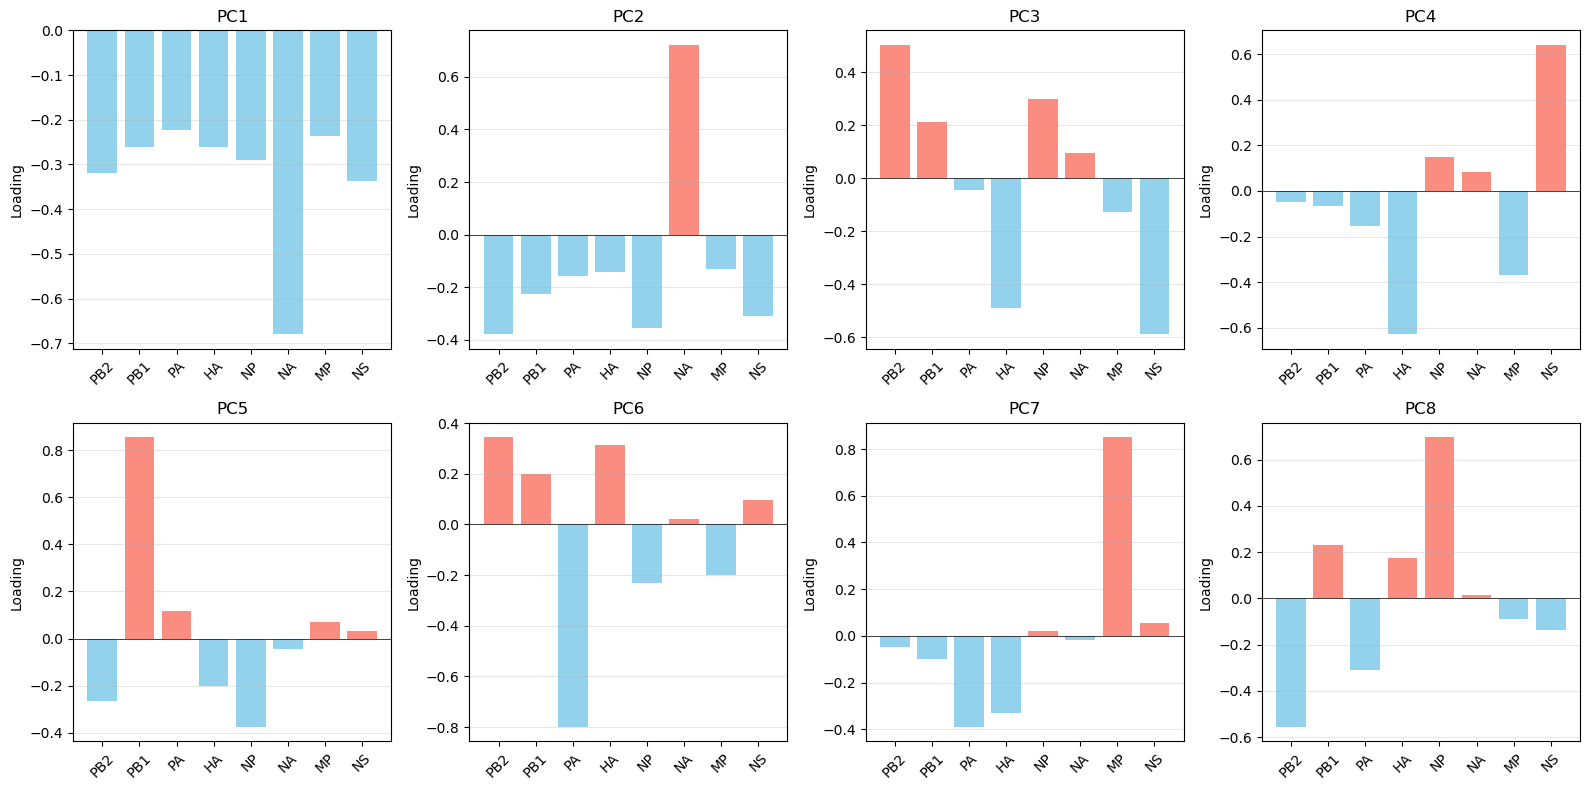

In [9]:
segment_names = ['PB2', 'PB1', 'PA', 'HA', 'NP', 'NA', 'MP', 'NS']  

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for component in range(8):
    ax = axes[component]
    loadings = mode0['U'][:, component]  # All 8 segments for this component
    
    colors = ['salmon' if l > 0 else 'skyblue' for l in loadings]
    ax.bar(segment_names, loadings, color=colors, alpha=0.9)
    ax.axhline(y=0, color='black', linewidth=0.5)
    ax.set_ylabel('Loading')
    ax.set_title(f'PC{component+1}')
    ax.grid(True, alpha=0.3, axis='y')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### 2. Principle Components of Segments 

#### 2.1 Get Sample Names

In [13]:
#parquet_folder = Path("/data/users/ltucker/influenzaData/pipeline/output/1_distances")
#files = sorted(parquet_folder.glob("*.parquet"))

indices_path = Path("/data/users/ltucker/influenzaData/pipeline/output/tensor/subsample_indices/indices_pct050_iter00_seed4000.npy")
selected_indices = np.load(indices_path)


sample_df = pd.read_parquet("/data/users/ltucker/influenzaData/pipeline/output/1_distances/distance_1.parquet")
sample_df = sample_df.set_index(sample_df["column00000"])
metadata = pd.DataFrame({"sample_id": sample_df.index[selected_indices]})
metadata

,sample_id
0,A/H5N0|A/duck/Jiangxi/5.28_NCNP12N3-OC/2018|PB...
1,A/H5N0|A/duck/Jiangxi/5.28_NCNP34N3-OC/2018|PB...
2,A/H5N0|A/duck/Zhejiang/12.28_HZBX012-O/2018|PB...
3,A/H5N1|A/African_barn_owl/South_Africa/2105042...
4,A/H5N1|A/African_black_oystercatcher/South_Afr...
...,...
11162,A_/_H7N3|A/chicken/Puebla/CPA-04451-16-CENASA-...
11163,A_/_H7N3|A/turkey/South_Carolina/20-010561-006...
11164,A_/_H7N8|A/turkey/Indiana/16/001403/1/2016|PB2...
11165,A_/_H7N9|A/chicken/Tennessee/17-008279-2/2017|...


In [37]:

# Parse metadata from sample IDs
# Header format: A_/_H7N9|A/chicken/Tennessee/17-007147-7/2017|PB2|1|EPI_ISL_276771|united states|americas|2017
metadata["country"] = metadata["sample_id"].str.split("|").str[5]
metadata["continent"] = metadata["sample_id"].str.split("|").str[6]
metadata["year"] = metadata["sample_id"].str.split("|").str[7]
# metadata["segment"] = metadata["sample_id"].str.split("|").str[2] # does not work as segements are convoluted; 

print(f"Metadata shape: {metadata.shape}")
print(f'''
      Unique countries: {metadata['country'].nunique()},
      Unique continent: {metadata['continent'].nunique()},
      Years: {metadata['year'].nunique()}
      ''')

Metadata shape: (11167, 5)

      Unique countries: 99,
      Unique continent: 6,
      Years: 47
      


,sample_id,country,continent,year,segment
0,A/H5N0|A/duck/Jiangxi/5.28_NCNP12N3-OC/2018|PB...,china,asia,2018,NaN
1,A/H5N0|A/duck/Jiangxi/5.28_NCNP34N3-OC/2018|PB...,china,asia,2018,NaN
2,A/H5N0|A/duck/Zhejiang/12.28_HZBX012-O/2018|PB...,china,asia,2018,NaN
3,A/H5N1|A/African_barn_owl/South_Africa/2105042...,south africa,africa,2021,NaN
4,A/H5N1|A/African_black_oystercatcher/South_Afr...,south africa,africa,2022,NaN
...,...,...,...,...,...
11162,A_/_H7N3|A/chicken/Puebla/CPA-04451-16-CENASA-...,mexico,americas,2016,NaN
11163,A_/_H7N3|A/turkey/South_Carolina/20-010561-006...,united states,americas,2020,NaN
11164,A_/_H7N8|A/turkey/Indiana/16/001403/1/2016|PB2...,india,asia,NA,NaN
11165,A_/_H7N9|A/chicken/Tennessee/17-008279-2/2017|...,united states,americas,2017,NaN


#### 2.2 Mode1 data 

##### 2.2.1 Get Mode1 Data

In [15]:

folder = Path("/data/users/ltucker/influenzaData/pipeline/output/tensor/svd_loadings_analysis")
mode1_files = sorted(folder.glob("svd_pct050_iter00_seed4000_mode1_*.npy"))
SVD_matrix = ["U", "V", "W"]
mode1 = dict()

for index, file in enumerate(mode1_files):
    print(f"Index: {index}. SVD: {SVD_matrix[index]} file: {file}")

    #open da file 
    mode1[SVD_matrix[index]] = np.load(file)

Index: 0. SVD: U file: /data/users/ltucker/influenzaData/pipeline/output/tensor/svd_loadings_analysis/svd_pct050_iter00_seed4000_mode1_U.npy
Index: 1. SVD: V file: /data/users/ltucker/influenzaData/pipeline/output/tensor/svd_loadings_analysis/svd_pct050_iter00_seed4000_mode1_V.npy
Index: 2. SVD: W file: /data/users/ltucker/influenzaData/pipeline/output/tensor/svd_loadings_analysis/svd_pct050_iter00_seed4000_mode1_W.npy


#### 2.2.2 plot countries and years

In [16]:
sample_loadings = pd.DataFrame(mode1['U'][:, 0:5])
metadata
loadings = pd.concat([metadata, sample_loadings], axis=1)
loadings.groupby("continent").sum()
loadings.groupby("year").sum()[0].iloc[0:5]


year
1975    0.023047
1978    0.011672
1979    0.011863
1980    0.034342
1981    0.025101
Name: 0, dtype: float64

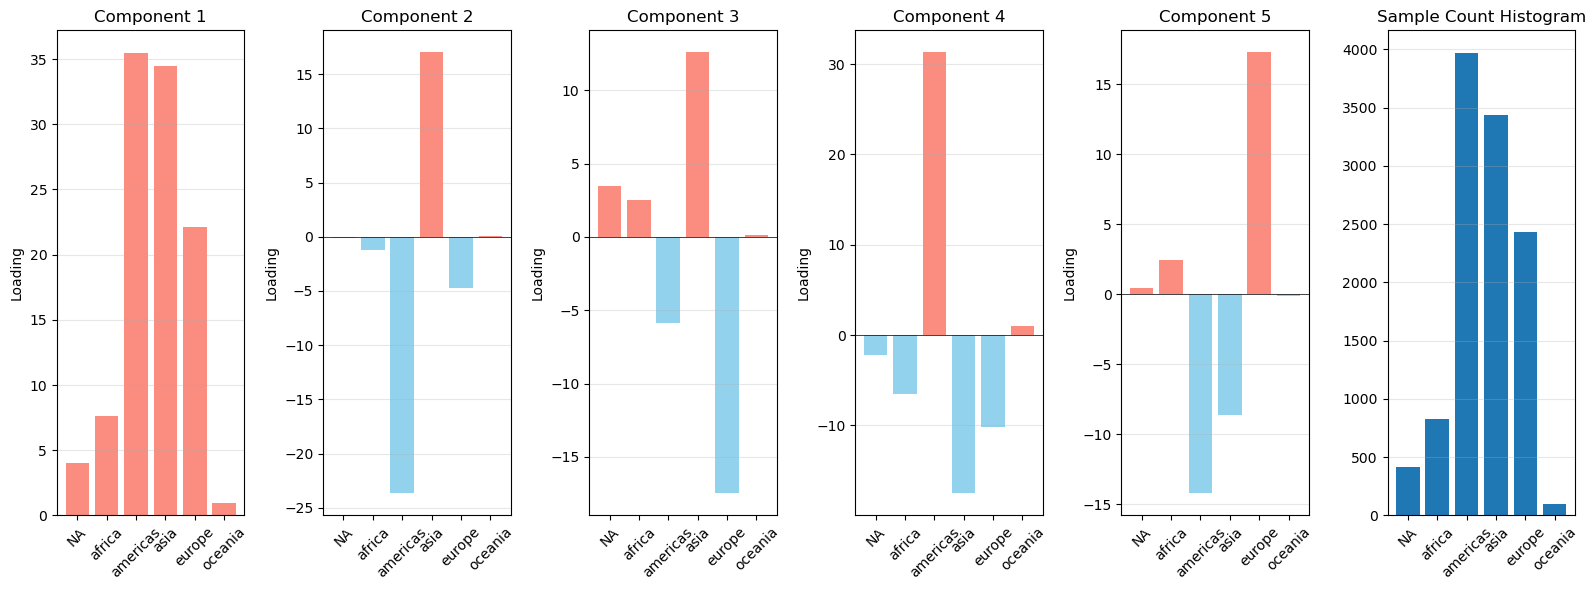

In [32]:
fig, axes = plt.subplots(1, 6, figsize=(16, 6))
axes = axes.flatten()

sample_loadings = pd.DataFrame(mode1['U'][:, 0:5])
loadings = pd.concat([metadata, sample_loadings], axis=1)

grouped = loadings.groupby("continent").sum()

continents = grouped.index

for i in range(5):
    colors = ['salmon' if l > 0 else 'skyblue' for l in grouped[i]]
    axes[i].bar(continents, grouped[i], color=colors, alpha=0.9)
    axes[i].set_title(f"Component {i+1}")
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].axhline(y=0, color='black', linewidth=0.5)
    axes[i].set_ylabel('Loading')
    axes[i].grid(True, alpha=0.3, axis='y')

    
counts = metadata.groupby("continent").size()
axes[5].bar(counts.index, counts.values)
axes[5].set_title("Sample Count Histogram")
axes[5].tick_params(axis='x', rotation=45)
axes[5].grid(True, alpha=0.3, axis='y')


plt.tight_layout()
plt.show()


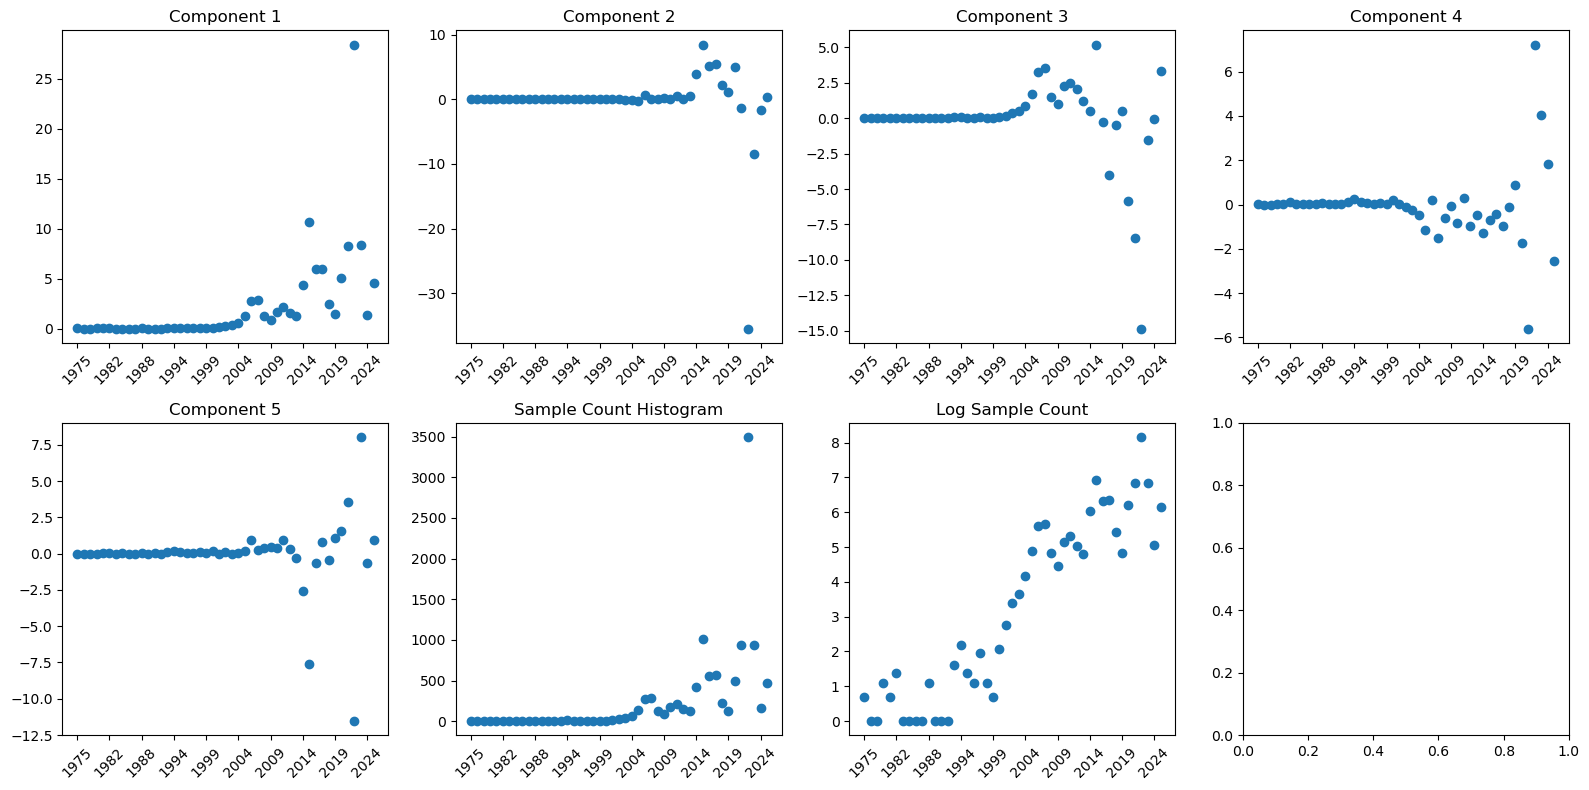

In [234]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

sample_loadings = pd.DataFrame(mode1['U'][:, 0:5])
loadings = pd.concat([metadata, sample_loadings], axis=1)

grouped = loadings.groupby("year").sum()

years = grouped.index
year_ticks = sorted(loadings["year"].unique())

for i in range(5):
    axes[i].scatter(years, grouped[i])
    axes[i].set_title(f"Component {i+1}")
    axes[i].set_xticks(year_ticks[::5])
    axes[i].tick_params(axis='x', rotation=45)

counts = metadata.groupby("year").size()
axes[i+1].scatter(counts.index, counts.values)
axes[i+1].set_title("Sample Count Histogram")
axes[i+1].tick_params(axis='x', rotation=45)
axes[i+1].set_xticks(year_ticks[::5])

axes[i+2].scatter(counts.index, np.log(counts.values))
axes[i+2].set_title("Log Sample Count")
axes[i+2].tick_params(axis='x', rotation=45)
axes[i+2].set_xticks(year_ticks[::5])

plt.tight_layout()
plt.show()


#### 2.3 Mode 2 data 

##### 2.2.1 Get Mode 2 Data

In [200]:

folder = Path("/data/users/ltucker/influenzaData/pipeline/output/tensor/svd_loadings_analysis")
mode2_files = sorted(folder.glob("svd_pct050_iter00_seed4000_mode2_*.npy"))
SVD_matrix = ["U", "V", "W"]
mode2 = dict()

for index, file in enumerate(mode2_files):
    print(f"Index: {index}. SVD: {SVD_matrix[index]} file: {file}")

    #open da file 
    mode2[SVD_matrix[index]] = np.load(file)

Index: 0. SVD: U file: /data/users/ltucker/influenzaData/pipeline/output/tensor/svd_loadings_analysis/svd_pct050_iter00_seed4000_mode2_U.npy
Index: 1. SVD: V file: /data/users/ltucker/influenzaData/pipeline/output/tensor/svd_loadings_analysis/svd_pct050_iter00_seed4000_mode2_V.npy
Index: 2. SVD: W file: /data/users/ltucker/influenzaData/pipeline/output/tensor/svd_loadings_analysis/svd_pct050_iter00_seed4000_mode2_W.npy


##### 2.2.2 plot countries and years

In [201]:
sample_loadings = pd.DataFrame(mode2['U'][:, 0:5])
metadata
loadings = pd.concat([metadata, sample_loadings], axis=1)
loadings.groupby("continent").sum()
loadings.groupby("year").sum()[0].iloc[0:5]


year
1975    0.023047
1978    0.011672
1979    0.011863
1980    0.034342
1981    0.025101
Name: 0, dtype: float64

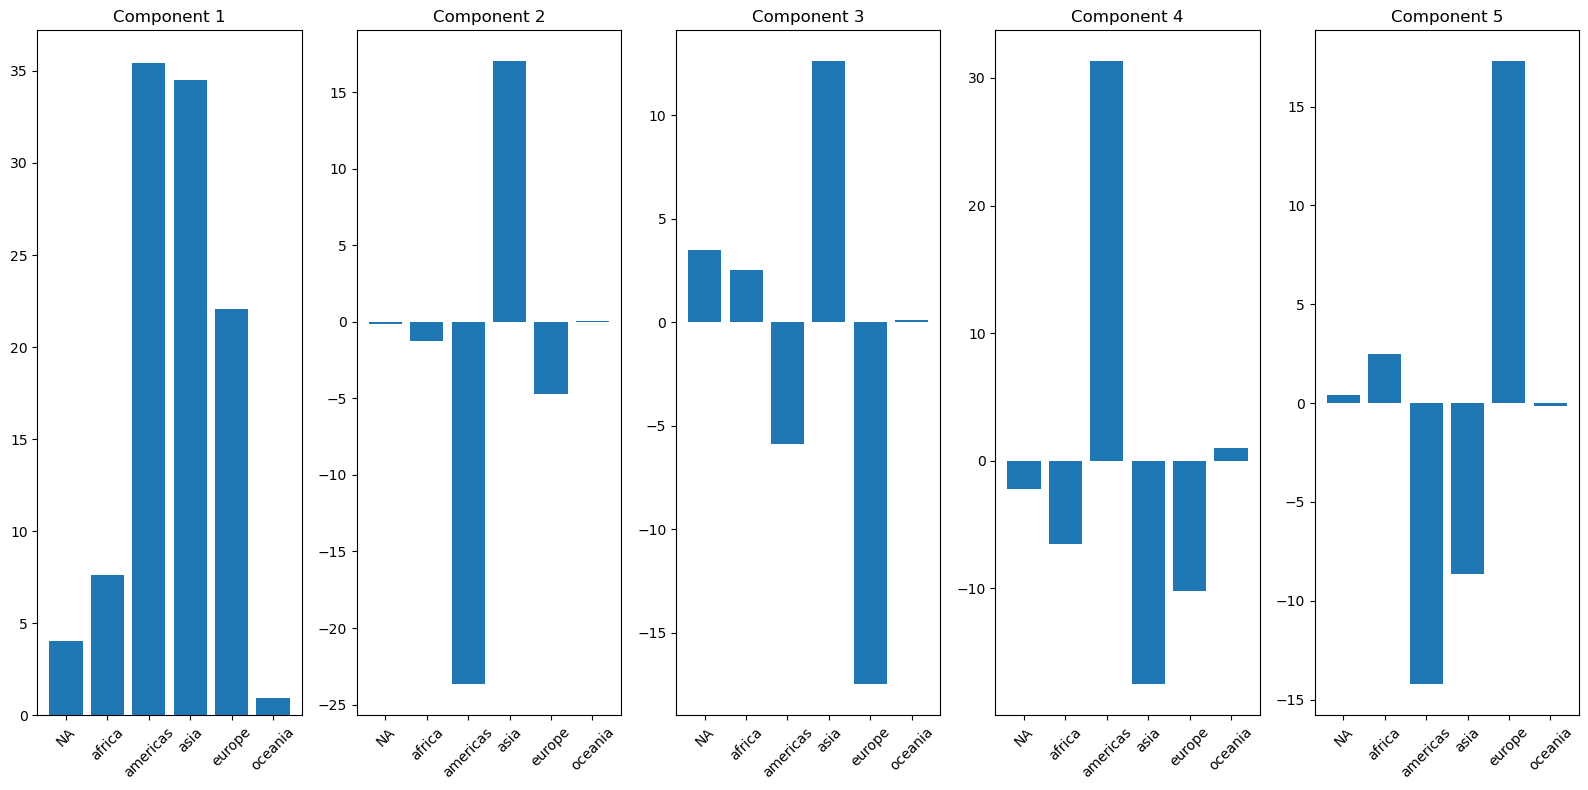

In [202]:
fig, axes = plt.subplots(1, 5, figsize=(16, 8))
axes = axes.flatten()

sample_loadings = pd.DataFrame(mode2['U'][:, 0:5])
loadings = pd.concat([metadata, sample_loadings], axis=1)

grouped = loadings.groupby("continent").sum()

continents = grouped.index

for i in range(5):
    axes[i].bar(continents, grouped[i])
    axes[i].set_title(f"Component {i+1}")
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


In [59]:
fig, axes = plt.subplots(2, 6, figsize=(16, 8))
axes = axes.flatten()

sample_loadings = pd.DataFrame(mode1['U'][:, 0:5])
loadings = pd.concat([metadata, sample_loadings], axis=1)

grouped = loadings.groupby("year").sum()
years = grouped.index

year_ticks = sorted(loadings["year"].unique())

for i in range(5):
    axes[i].scatter(years, grouped[i])
    axes[i].set_title(f"Component {i+1}")
    axes[i].set_xticks(year_ticks[::5])
    axes[i].tick_params(axis='x', rotation=90)

counts = metadata.groupby("year").size()
axes[5].scatter(counts.index, counts.values)
axes[5].set_title("Sample Count")
axes[5].tick_params(axis='x', rotation=45)

# ---------- Log 
for i in range(5):
    axes[i+6].scatter(years, np.log1p(grouped[i]))  # safe log
    axes[i+6].set_title(f"Log Component {i+1}")
    axes[i+6].tick_params(axis='x', rotation=90)

axes[11].scatter(counts.index, np.log1p(counts.values))
axes[11].set_title("Log Sample Count")
axes[11].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

/opt/conda/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


ValueError: cannot convert float NaN to integer

Error in callback <function _draw_all_if_interactive at 0x7f9b630b0040> (for post_execute):


ValueError: cannot convert float NaN to integer

ValueError: cannot convert float NaN to integer

<Figure size 1600x800 with 12 Axes>